# Step 1: Import helpful libraries

In [1]:
# Regular imports
import numpy as np
import pandas as pd
import sklearn as sk
import lightgbm as lhgbm

#For Visualizations
import pandas_profiling as pp
import matplotlib as mpl
import seaborn as sns

#Ensemble Models
import xgboost as xgb

import matplotlib.pyplot as plt
%matplotlib inline
sns.set()
plt.style.use('classic')
pd.set_option('max_columns', None)

from sklearn.linear_model import *


#To Split Data 
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV, cross_val_score, KFold

#To Preprocess Data 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder, FunctionTransformer, OneHotEncoder, Normalizer
from sklearn.impute import SimpleImputer
from imblearn import FunctionSampler


#To Pipeline the process 
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
#from lineartree import  LinearTreeRegressor, LinearBoostRegressor
from sklearn.pipeline import Pipeline

# used in Utilities/Functions section
from scipy import stats

## Import Models
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from mlxtend.regressor import StackingCVRegressor


# Import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from xgboost import plot_importance


# variables
target_feature = 'target' 
random_seed    = 42
max_rows_per_class  = 100 ## use high number (300000) to get all data 
full_run ='Y'  

In [2]:
#Python libraries and their versions used for this problem
print('SciKit Learn:',sk.__version__)
print('Pandas:',pd.__version__)
print('Numpy:',np.__version__)
print('Seaborn:',sns.__version__)
print('MatPlot Library:', mpl.__version__)
print('XG Boost:',xgb.__version__)
print('Pandas Profiling:', pp.__version__)
print('LightGBM:', lhgbm.__version__)


SciKit Learn: 0.24.1
Pandas: 1.1.5
Numpy: 1.19.5
Seaborn: 0.11.1
MatPlot Library: 3.4.1
XG Boost: 1.4.0
Pandas Profiling: 2.11.0
LightGBM: 3.2.0


In [3]:
#Define Utilities/Functions

# Function to show essential info about Dataset
def ShowEssentialInfo(df):
    # Check No of rows & columns
    print("\n",'*** Shape:',df.shape)

    # Check data
    print("\n",'*** Data:',df.head(10))
    
    # Check Info about Object types of data
    print("\n",'*** Info:')
    df.info()

    #Count missing values 
    print("\n",'*** Missing values:')
    print(df.isnull().sum())

    #Data Statistics
    print("\n",'*** Data Statistics:')
    print(df.describe(include='all'))
    
    #Data Skew
    #print("\n",'*** Skewness:')
    #print('#** skewness is a degree of asymmetry observed in a probability distribution that deviates from the symmetrical normal distribution (bell curve) in a given set of data')
    #print('#** If the skewness is between -0.5 & 0.5, the data are nearly symmetrical.')
    #print('#** If the skewness is between -1 & -0.5 (negative skewed) or between 0.5 & 1(positive skewed), the data are slightly skewed.')
    #print('#** If the skewness is lower than -1 (negative skewed) or greater than 1 (positive skewed), the data are extremely skewed.')
    #print(df.skew(axis=1))
 
    #Data Kurtosis
    #print("\n",'*** Kurtosis:')
    #print('#** Kurtosis quantifies shape of the distribution and the degree of presence of outliers in the distribution.')
    #print('# High kurtosis in a data set is an indicator that data has heavy outliers.')
    #print('# Low kurtosis in a data set is an indicator that data has lack of outliers.')
    #print('# If kurtosis value + means pointy and — means flat.')    
    #print(df.kurt(axis=1))
 
    

def treatoutliers(df=None, columns=None, factor=1.5, method='IQR', treatment='cap'):

    for column in columns:
        if method == 'STD':
            permissable_std = factor * df[column].std()
            col_mean = df[column].mean()
            floor, ceil = col_mean - permissable_std, col_mean + permissable_std
        elif method == 'IQR':
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            floor, ceil = Q1 - factor * IQR, Q3 + factor * IQR
#         print(floor, ceil)
        if treatment == 'remove':
            print(treatment, column)
            df = df[(df[column] >= floor) & (df[column] <= ceil)]
        elif treatment == 'cap':
            print(treatment, column)
            df[column] = df[column].clip(floor, ceil)

    return df
    
def get_sample_dataset(df, categorical_features, max_rows_per_class=1000):
    rows = []
    df_sub = pd.DataFrame()
    for x in categorical_features:
        for idx,name in enumerate(df[x].value_counts().index.tolist()):
            nrows = df[x].value_counts()[idx]
            nsample = min(nrows, max_rows_per_class)
            data = df.loc[df[x] == name].sample(n=nsample, random_state=random_seed)
            #print(data.info())
            df_sub = df_sub.append(data)
    return df_sub


def log_transform(x):
    return np.log(x + 1)

def exp_transform(x):
    return np.exp(x)



# Step 2: Load the data

Next, we'll load the training and test data.  

We set `index_col=0` in the code cell below to use the `id` column to index the DataFrame.

In [4]:
# Load the training data
X_full = pd.read_csv("../input/30-days-of-ml/train.csv", index_col=0)
X_test_full = pd.read_csv("../input/30-days-of-ml/test.csv", index_col=0)

X_all = pd.concat([X_full,X_test_full]) 


In [5]:
## Check for Data types & Missing data
ShowEssentialInfo(X_full)


 *** Shape: (300000, 25)

 *** Data:    cat0 cat1 cat2 cat3 cat4 cat5 cat6 cat7 cat8 cat9     cont0     cont1  \
id                                                                         
1     B    B    B    C    B    B    A    E    C    N  0.201470 -0.014822   
2     B    B    A    A    B    D    A    F    A    O  0.743068  0.367411   
3     A    A    A    C    B    D    A    D    A    F  0.742708  0.310383   
4     B    B    A    C    B    D    A    E    C    K  0.429551  0.620998   
6     A    A    A    C    B    D    A    E    A    N  1.058291  0.367492   
7     A    B    A    C    B    D    A    E    G    F  0.402056  0.837058   
8     B    A    A    A    B    D    A    E    C    F  0.743661  0.234794   
9     A    A    A    C    B    B    A    E    A    M  0.887959  0.482799   
10    A    B    A    C    B    D    A    E    G    I  0.523472  0.492059   
11    A    A    A    A    B    B    A    E    E    M  0.503013  0.551163   

       cont2     cont3     cont4     cont5     co

No Null values in Data

In [6]:
ShowEssentialInfo(X_test_full)


 *** Shape: (200000, 24)

 *** Data:    cat0 cat1 cat2 cat3 cat4 cat5 cat6 cat7 cat8 cat9     cont0     cont1  \
id                                                                         
0     B    B    B    C    B    B    A    E    E    I  0.296227  0.686757   
5     A    B    A    C    B    C    A    E    C    H  0.543707  0.364761   
15    B    A    A    A    B    B    A    E    D    K  0.408961  0.296129   
16    B    B    A    C    B    D    A    E    A    N  1.031239  0.356062   
17    B    B    A    C    B    C    A    E    C    F  0.530447  0.729004   
19    B    B    B    C    B    B    A    E    E    F  0.414021  0.795609   
20    A    A    A    C    B    D    A    E    G    K  0.745064  0.225120   
21    B    B    A    C    B    D    A    E    A    K  0.520282  0.226399   
23    A    A    A    C    B    B    A    E    E    N  0.406087  0.620158   
29    A    A    A    C    B    D    A    E    A    I  0.963659  0.353558   

       cont2     cont3     cont4     cont5     co

In [7]:
# Identify Numeric / Categorical features this would be used to transform features later 

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_features  = [cname for cname in X_full.columns if
                    X_full[cname].dtype in ["object"]]

# Select numerical columns
numeric_features  = [cname for cname in X_full.columns if 
                X_full[cname].dtype in ['int64', 'float64']
                 ]

# Keep selected columns only
my_features = categorical_features + numeric_features

print('categorical_features({}):'.format(len(categorical_features)),categorical_features)
print('numeric_features({}):'.format(len(numeric_features)), numeric_features)
print('my_features:({})'.format(len(my_features)), my_features)


categorical_features(10): ['cat0', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9']
numeric_features(15): ['cont0', 'cont1', 'cont2', 'cont3', 'cont4', 'cont5', 'cont6', 'cont7', 'cont8', 'cont9', 'cont10', 'cont11', 'cont12', 'cont13', 'target']
my_features:(25) ['cat0', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9', 'cont0', 'cont1', 'cont2', 'cont3', 'cont4', 'cont5', 'cont6', 'cont7', 'cont8', 'cont9', 'cont10', 'cont11', 'cont12', 'cont13', 'target']


In [8]:
# Identify Numeric / Categorical features this would be used to transform features later 

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_features  = [cname for cname in X_full.columns if
                    X_full[cname].dtype == "object"]

# Select numerical columns
numeric_features  = [cname for cname in X_full.columns if 
                X_full[cname].dtype in ['int64', 'float64']
                 ]

# Keep selected columns only
my_features = categorical_features + numeric_features

print('categorical_features({}):'.format(len(categorical_features)),categorical_features)
print('numeric_features({}):'.format(len(numeric_features)), numeric_features)
print('my_features:({})'.format(len(my_features)), my_features)

categorical_features(10): ['cat0', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9']
numeric_features(15): ['cont0', 'cont1', 'cont2', 'cont3', 'cont4', 'cont5', 'cont6', 'cont7', 'cont8', 'cont9', 'cont10', 'cont11', 'cont12', 'cont13', 'target']
my_features:(25) ['cat0', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9', 'cont0', 'cont1', 'cont2', 'cont3', 'cont4', 'cont5', 'cont6', 'cont7', 'cont8', 'cont9', 'cont10', 'cont11', 'cont12', 'cont13', 'target']


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#print(X_random_subset['cat9'].value_counts(()).index.tolist())

## Feature Selection using variance_inflation_factor
def cal_vif(X, thresh=6):
    output = pd.DataFrame()
    k =X_vif.shape[1]
    vif = [variance_inflation_factor(X_vif.values, i) for i in range(k)]
    for i in range(1,k):
        print('Iteration No ', i)
        print(vif)
        a = int(np.argmax(vif))
        if(vif[a]<=thresh):
            print('break')
            break
        if(i==1):
            print('i=1', i)
            output=X_vif.drop(X_vif.columns[a], axis=1)  
        elif(i>1):
            print('i>1', i)
            output=output.drop(output.columns[a], axis=1)
        l = len(output.columns)    
        vif=[variance_inflation_factor(output.values, j) for j in range(l)]
    return(output)     


# creating dummies for categorical_features

# the independent variables set
X_vif=X_all.copy()
y_vif=X_vif[target_feature]
X_vif=X_vif.drop(target_feature,1)

#{'A':0, 'B':1, 'C':2, 'D':3, 'E':5, 'F':6,'G':7,'H':8,'I':9,'J':10,'K':11,'L':12,'M':13,'N':14,'O':15}
X_vif[categorical_features] = X_vif[categorical_features] = X_vif[categorical_features].applymap(lambda x: ord(x)-65)

#selected_features = pd.DataFrame()
selected_features = cal_vif(X_vif)
#selected_features = X_full.head(5)
selected_features.head()

Iteration No  1
[1.5704919169481275, 2.0712806309846146, 1.2541594358889085, 8.689682158434891, 33.52606130776251, 9.3694443452639, 1.0201277148401626, 33.56737580632182, 2.8050557359574064, 5.511208387075926, 8.922957766432845, 5.486579992650917, 5.7194267505733745, 6.668113113472833, 5.203385196947982, 9.500326305018724, 6.354019563600081, 9.076085025536779, 7.932507680016646, 8.83814390393758, 6.399000971030355, 7.15306453439146, 8.756648618792457, 6.080140647310945]
i=1 1
Iteration No  2
[1.568259905300718, 2.045055828434676, 1.2500909268997014, 8.48406635092556, 27.888727701735142, 9.369211071885099, 1.0200902159977163, 2.7731707687407376, 5.434103428342132, 8.914042258195279, 5.410606141339528, 5.370362932688894, 6.619948992662664, 5.091032341715771, 9.498365021594552, 6.297830857472086, 9.043465579957909, 7.926364571310054, 8.835440220398628, 6.396669180237735, 7.113424852691218, 8.75622277778469, 6.007157113971287]
i>1 2
Iteration No  3
[1.5640139356237377, 1.9969286253570737, 

,cat0,cat1,cat2,cat6,cat8,cat9,cont1,cont2,cont3,cont4,cont6,cont10,cont11,cont13
id,,,,,,,,,,,,,,
1,1,1,1,0,2,13,-0.014822,0.669699,0.136278,0.610706,0.160266,0.237281,0.377873,0.869850
2,1,1,0,0,0,14,0.367411,1.021605,0.365798,0.276853,0.558922,0.906013,0.921701,0.465083
3,0,0,0,0,0,5,0.310383,-0.012673,0.576957,0.285074,0.375348,0.748809,0.620126,0.763846
4,1,1,0,0,2,10,0.620998,0.577942,0.280610,0.284667,0.239061,0.346010,0.714610,0.280682
6,0,0,0,0,0,13,0.367492,-0.052389,0.232407,0.287595,0.420667,1.000773,0.776742,0.250823


In [10]:
selected_features['target'] = y_vif

In [11]:
exclude_columns = set(list(X_full.columns)) - set(list(selected_features.columns))
print(exclude_columns)


{'cont0', 'cont7', 'cont12', 'cat5', 'cat4', 'cont9', 'cat7', 'cat3', 'cont8', 'cont5'}


In [12]:
ShowEssentialInfo(selected_features)


 *** Shape: (500000, 15)

 *** Data:     cat0  cat1  cat2  cat6  cat8  cat9     cont1     cont2     cont3  \
id                                                                     
1      1     1     1     0     2    13 -0.014822  0.669699  0.136278   
2      1     1     0     0     0    14  0.367411  1.021605  0.365798   
3      0     0     0     0     0     5  0.310383 -0.012673  0.576957   
4      1     1     0     0     2    10  0.620998  0.577942  0.280610   
6      0     0     0     0     0    13  0.367492 -0.052389  0.232407   
7      0     1     0     0     6     5  0.837058  0.737991  0.778429   
8      1     0     0     0     2     5  0.234794  0.339026  0.424034   
9      0     0     0     0     0    12  0.482799  0.674588  0.584811   
10     0     1     0     0     6     8  0.492059  0.165440  0.749995   
11     0     0     0     0     4    12  0.551163  0.622871  0.471560   

       cont4     cont6    cont10    cont11    cont13    target  
id                              

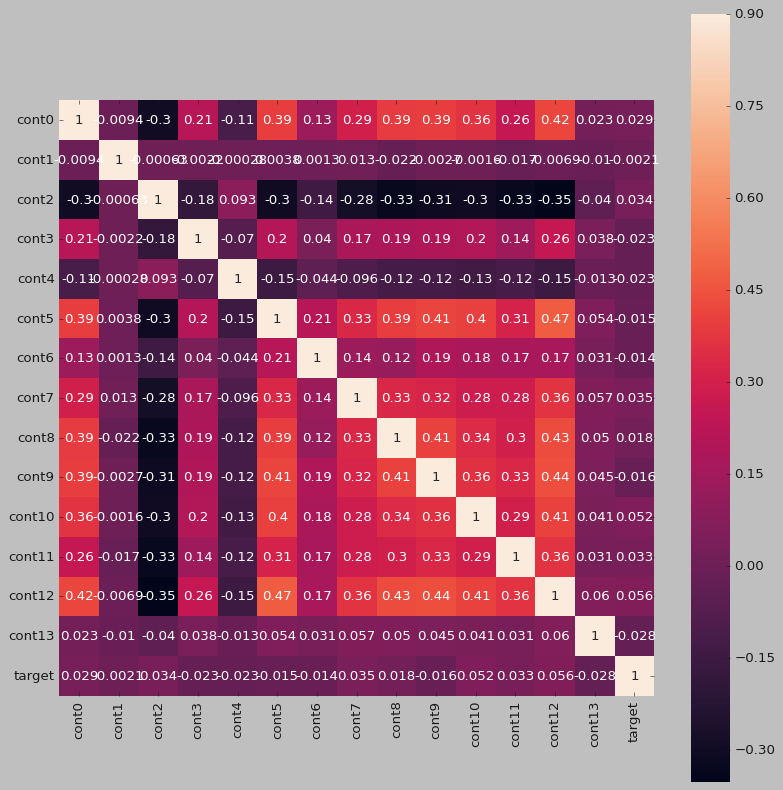

In [13]:
## Correlations
correlations = X_full.corr()
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(correlations, square=True, cbar=True, annot=True, vmax=.9);

In [14]:
#Correlation with output variable
cor_target = abs(correlations[target_feature])
#Selecting highly correlated features
relevant_features = cor_target[cor_target>0]
relevant_features

cont0     0.028819
cont1     0.002096
cont2     0.034280
cont3     0.022759
cont4     0.023132
cont5     0.015058
cont6     0.013807
cont7     0.035143
cont8     0.017740
cont9     0.015726
cont10    0.052468
cont11    0.033378
cont12    0.055829
cont13    0.028189
target    1.000000
Name: target, dtype: float64

All features are weakly correlated to target feature

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:331: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


array([[<AxesSubplot:title={'center':'cont0'}>,
        <AxesSubplot:title={'center':'cont1'}>,
        <AxesSubplot:title={'center':'cont2'}>,
        <AxesSubplot:title={'center':'cont3'}>],
       [<AxesSubplot:title={'center':'cont4'}>,
        <AxesSubplot:title={'center':'cont5'}>,
        <AxesSubplot:title={'center':'cont6'}>,
        <AxesSubplot:title={'center':'cont7'}>],
       [<AxesSubplot:title={'center':'cont8'}>,
        <AxesSubplot:title={'center':'cont9'}>,
        <AxesSubplot:title={'center':'cont10'}>,
        <AxesSubplot:title={'center':'cont11'}>],
       [<AxesSubplot:title={'center':'cont12'}>,
        <AxesSubplot:title={'center':'cont13'}>,
        <AxesSubplot:title={'center':'target'}>, <AxesSubplot:>]],
      dtype=object)

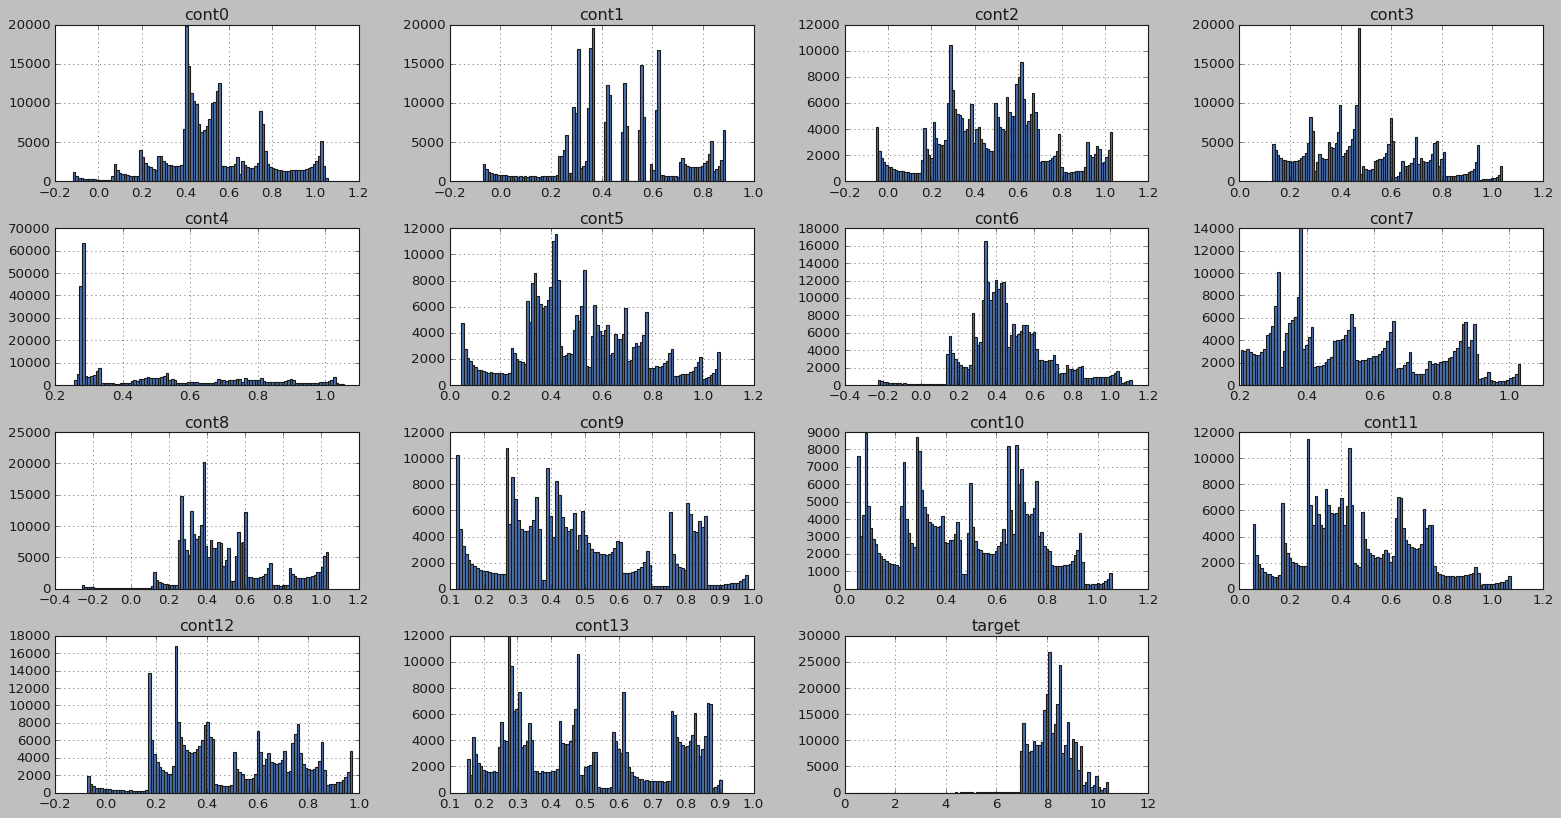

In [15]:
## Data Distribution of numeric features 
X_full[numeric_features].hist(bins=100, figsize=(24,12))

array([[<AxesSubplot:title={'center':'cont0'}>,
        <AxesSubplot:title={'center':'cont1'}>,
        <AxesSubplot:title={'center':'cont2'}>,
        <AxesSubplot:title={'center':'cont3'}>],
       [<AxesSubplot:title={'center':'cont4'}>,
        <AxesSubplot:title={'center':'cont5'}>,
        <AxesSubplot:title={'center':'cont6'}>,
        <AxesSubplot:title={'center':'cont7'}>],
       [<AxesSubplot:title={'center':'cont8'}>,
        <AxesSubplot:title={'center':'cont9'}>,
        <AxesSubplot:title={'center':'cont10'}>,
        <AxesSubplot:title={'center':'cont11'}>],
       [<AxesSubplot:title={'center':'cont12'}>,
        <AxesSubplot:title={'center':'cont13'}>,
        <AxesSubplot:title={'center':'target'}>, <AxesSubplot:>]],
      dtype=object)

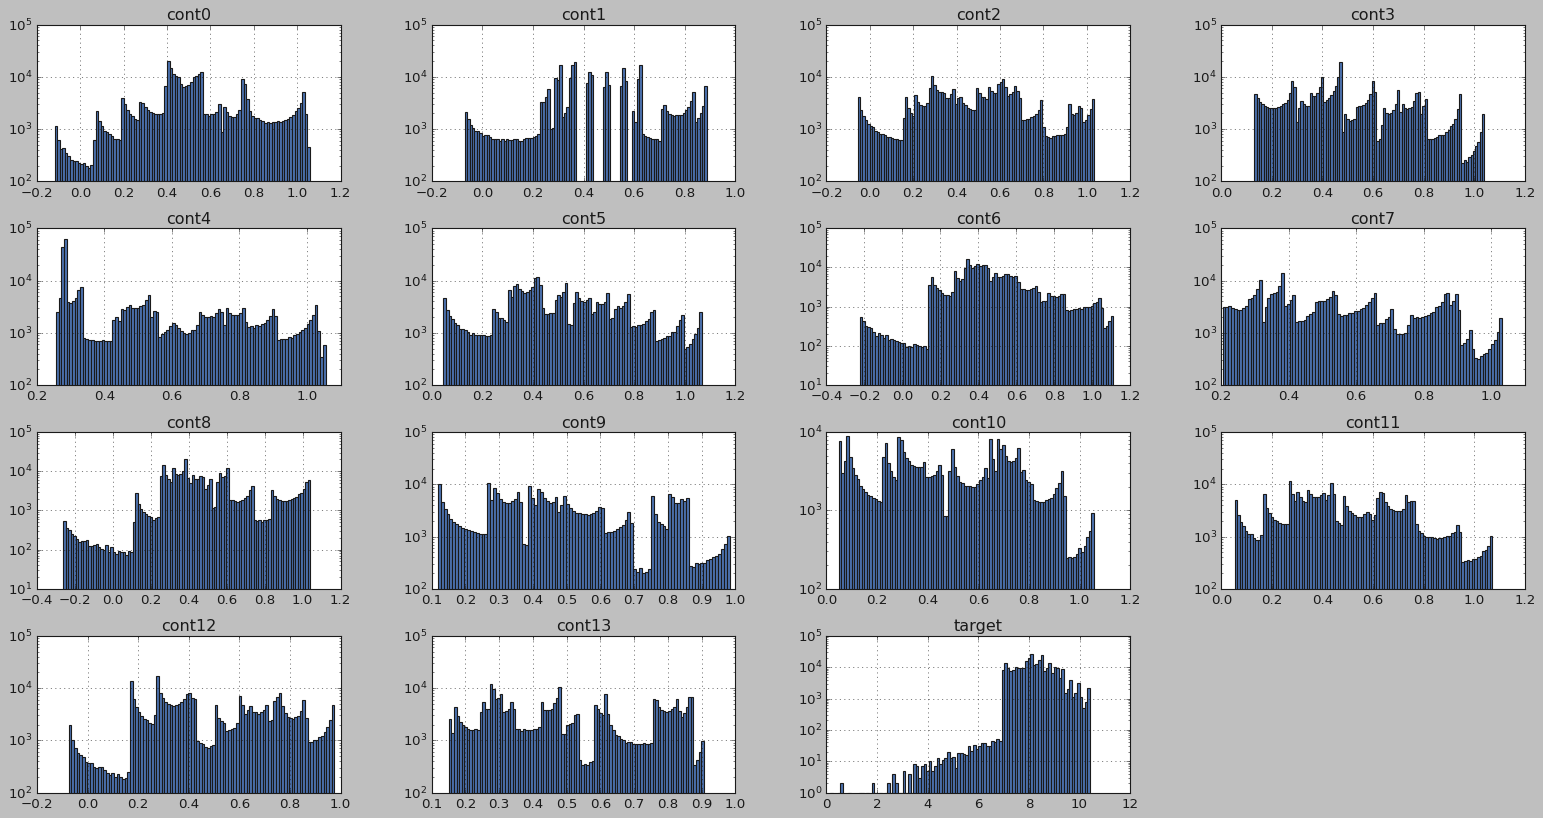

In [16]:
## Verify distribution with log transform 
X_full[numeric_features].hist(bins=100, figsize=(24,12), log = True)

The above distribution looks good after log transformation

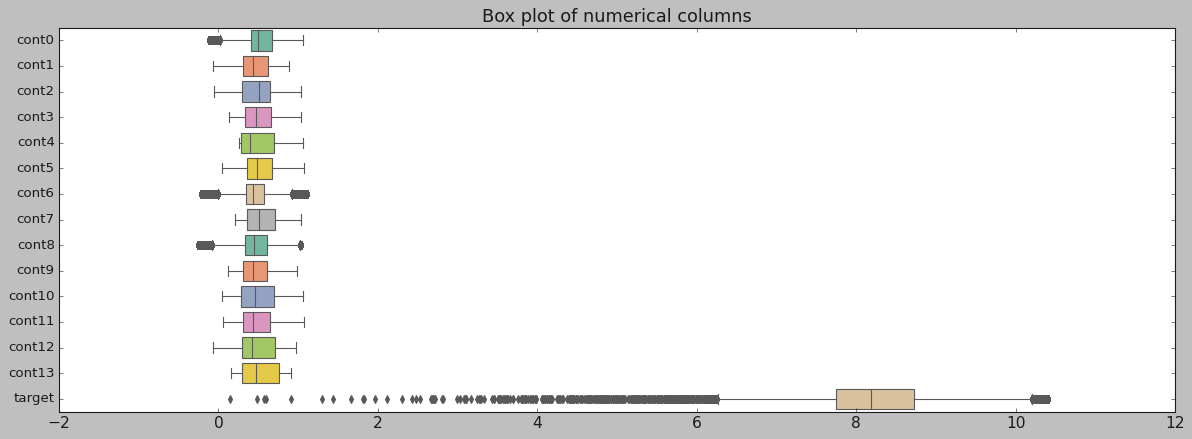

In [17]:
## Box Plot for Outliers
fig = plt.figure(figsize=(18,6))
sns.boxplot(data=X_full[numeric_features], orient="h", palette="Set2");
plt.xticks(fontsize= 14)
plt.title('Box plot of numerical columns', fontsize=16);

Looks like few outliers in Cont0, Cont6, Cont8, target columns.
Lets check the ouliers in  target column now.

# Step 3: Prepare the data



In [18]:
# Deal with duplicate rows
X_full[my_features].drop_duplicates()

,cat0,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,cont0,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,target
id,,,,,,,,,,,,,,,,,,,,,,,,,
1,B,B,B,C,B,B,A,E,C,N,0.201470,-0.014822,0.669699,0.136278,0.610706,0.400361,0.160266,0.310921,0.389470,0.267559,0.237281,0.377873,0.322401,0.869850,8.113634
2,B,B,A,A,B,D,A,F,A,O,0.743068,0.367411,1.021605,0.365798,0.276853,0.533087,0.558922,0.516294,0.594928,0.341439,0.906013,0.921701,0.261975,0.465083,8.481233
3,A,A,A,C,B,D,A,D,A,F,0.742708,0.310383,-0.012673,0.576957,0.285074,0.650609,0.375348,0.902567,0.555205,0.843531,0.748809,0.620126,0.541474,0.763846,8.364351
4,B,B,A,C,B,D,A,E,C,K,0.429551,0.620998,0.577942,0.280610,0.284667,0.668980,0.239061,0.732948,0.679618,0.574844,0.346010,0.714610,0.540150,0.280682,8.049253
6,A,A,A,C,B,D,A,E,A,N,1.058291,0.367492,-0.052389,0.232407,0.287595,0.686964,0.420667,0.648182,0.684501,0.956692,1.000773,0.776742,0.625849,0.250823,7.972260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499993,B,B,A,A,B,D,A,E,A,I,0.697124,0.483452,0.297770,0.195821,0.307883,0.769792,0.450538,0.934360,1.005077,0.853726,0.422541,1.063463,0.697685,0.506404,7.945605
499996,A,B,A,C,B,B,A,E,E,F,0.446200,0.715135,0.610931,0.601730,0.736713,0.528056,0.508502,0.358247,0.257825,0.433525,0.301015,0.268447,0.577055,0.823611,7.326118
499997,B,B,A,C,B,C,A,E,G,F,0.544279,0.060937,0.590955,0.905308,0.277074,0.688747,0.372425,0.364936,0.383224,0.551825,0.661007,0.629606,0.714139,0.245732,8.706755


No Duplicate Rows in the data set...

In [19]:
# Deal with Outliers

#remove outliers from target column 
#for colName in [['target']]:
    #X_full = treatoutliers(df=X_full,columns=colName, treatment='remove')         
    
#Quantile-based Flooring and Capping
for colName in [['target','cont0','cont6','cont8']]:
    X_full = treatoutliers(df=X_full,columns=colName, treatment='cap')      
    
ShowEssentialInfo(X_full)

cap target
cap cont0
cap cont6
cap cont8

 *** Shape: (300000, 25)

 *** Data:    cat0 cat1 cat2 cat3 cat4 cat5 cat6 cat7 cat8 cat9     cont0     cont1  \
id                                                                         
1     B    B    B    C    B    B    A    E    C    N  0.201470 -0.014822   
2     B    B    A    A    B    D    A    F    A    O  0.743068  0.367411   
3     A    A    A    C    B    D    A    D    A    F  0.742708  0.310383   
4     B    B    A    C    B    D    A    E    C    K  0.429551  0.620998   
6     A    A    A    C    B    D    A    E    A    N  1.058291  0.367492   
7     A    B    A    C    B    D    A    E    G    F  0.402056  0.837058   
8     B    A    A    A    B    D    A    E    C    F  0.743661  0.234794   
9     A    A    A    C    B    B    A    E    A    M  0.887959  0.482799   
10    A    B    A    C    B    D    A    E    G    I  0.523472  0.492059   
11    A    A    A    A    B    B    A    E    E    M  0.503013  0.551163   

       c

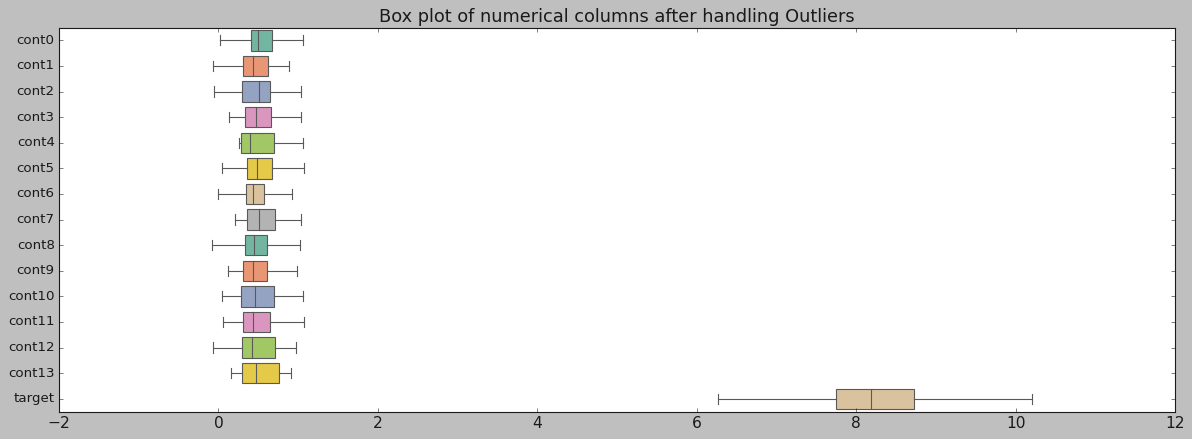

In [20]:
## Box Plot for Outliers
fig = plt.figure(figsize=(18,6))
sns.boxplot(data=X_full[numeric_features], orient="h", palette="Set2");
plt.xticks(fontsize= 14)
plt.title('Box plot of numerical columns after handling Outliers', fontsize=16);

In [21]:
# Deal with missing data
## No Missing data in this dataset :)

The next code cell separates the target (which we assign to `y`) from the training features.

In [22]:
if full_run == 'N' :
    X_random_subset = get_sample_dataset(X_full, categorical_features, max_rows_per_class)
else:
    X_random_subset = X_full.copy()
    
ShowEssentialInfo(X_random_subset)


 *** Shape: (300000, 25)

 *** Data:    cat0 cat1 cat2 cat3 cat4 cat5 cat6 cat7 cat8 cat9     cont0     cont1  \
id                                                                         
1     B    B    B    C    B    B    A    E    C    N  0.201470 -0.014822   
2     B    B    A    A    B    D    A    F    A    O  0.743068  0.367411   
3     A    A    A    C    B    D    A    D    A    F  0.742708  0.310383   
4     B    B    A    C    B    D    A    E    C    K  0.429551  0.620998   
6     A    A    A    C    B    D    A    E    A    N  1.058291  0.367492   
7     A    B    A    C    B    D    A    E    G    F  0.402056  0.837058   
8     B    A    A    A    B    D    A    E    C    F  0.743661  0.234794   
9     A    A    A    C    B    B    A    E    A    M  0.887959  0.482799   
10    A    B    A    C    B    D    A    E    G    I  0.523472  0.492059   
11    A    A    A    A    B    B    A    E    E    M  0.503013  0.551163   

       cont2     cont3     cont4     cont5     co

In [23]:
# Remove rows with missing target, separate target from predictors
X_random_subset.dropna(axis=0, subset=[target_feature], inplace=True)
y = X_random_subset.pop(target_feature)


#Prieview features
ShowEssentialInfo(X_random_subset)



 *** Shape: (300000, 24)

 *** Data:    cat0 cat1 cat2 cat3 cat4 cat5 cat6 cat7 cat8 cat9     cont0     cont1  \
id                                                                         
1     B    B    B    C    B    B    A    E    C    N  0.201470 -0.014822   
2     B    B    A    A    B    D    A    F    A    O  0.743068  0.367411   
3     A    A    A    C    B    D    A    D    A    F  0.742708  0.310383   
4     B    B    A    C    B    D    A    E    C    K  0.429551  0.620998   
6     A    A    A    C    B    D    A    E    A    N  1.058291  0.367492   
7     A    B    A    C    B    D    A    E    G    F  0.402056  0.837058   
8     B    A    A    A    B    D    A    E    C    F  0.743661  0.234794   
9     A    A    A    C    B    B    A    E    A    M  0.887959  0.482799   
10    A    B    A    C    B    D    A    E    G    I  0.523472  0.492059   
11    A    A    A    A    B    B    A    E    E    M  0.503013  0.551163   

       cont2     cont3     cont4     cont5     co

In [24]:
# A scatter plot matrix is a grid (or matrix) of scatter plots used to visualize bivariate relationships between combinations of variables. 
# Each scatter plot in the matrix visualizes the relationship between a pair of variables, allowing many relationships to be explored in one chart.

#pd.plotting.scatter_matrix(X_random_subset[:1000], figsize=(30, 20), alpha=0.2)



In [25]:
# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X_random_subset, y, 
                                                                train_size=0.9, test_size=0.1,
                                                                random_state=0)

In [26]:
# Identify Numeric / Categorical features this would be used to transform features later 

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_features  = [cname for cname in X_full.columns if
                    X_full[cname].dtype in ["object"] and cname not in exclude_columns
                        ]

# Select numerical columns
numeric_features  = [cname for cname in X_full.columns if 
                X_full[cname].dtype in ['int64', 'float64'] and
                     cname not in exclude_columns
                 ]

#remove target column from Numeric / categorical features
if numeric_features.count(target_feature) == 1:
    numeric_features.remove(target_feature)
elif  categorical_features.count(target_feature) == 1:
    categorical_features.remove(target_feature)

# Keep selected columns only
my_features = categorical_features + numeric_features

print('categorical_features({}):'.format(len(categorical_features)),categorical_features)
print('numeric_features({}):'.format(len(numeric_features)), numeric_features)
print('my_features:({})'.format(len(my_features)), my_features)

categorical_features(6): ['cat0', 'cat1', 'cat2', 'cat6', 'cat8', 'cat9']
numeric_features(8): ['cont1', 'cont2', 'cont3', 'cont4', 'cont6', 'cont10', 'cont11', 'cont13']
my_features:(14) ['cat0', 'cat1', 'cat2', 'cat6', 'cat8', 'cat9', 'cont1', 'cont2', 'cont3', 'cont4', 'cont6', 'cont10', 'cont11', 'cont13']


In [27]:
X_train = X_train_full[my_features]
X_valid = X_valid_full[my_features]
X_test = X_test_full[my_features]

In [28]:
ShowEssentialInfo(X_train)


 *** Shape: (270000, 14)

 *** Data:        cat0 cat1 cat2 cat6 cat8 cat9     cont1     cont2     cont3     cont4  \
id                                                                             
460905    A    B    A    B    E    F  0.253177  0.194075  0.596032  0.889253   
495259    B    A    B    A    C    F  0.304675  0.441560  0.236838  0.896394   
428788    A    B    B    A    E    K  0.307117  0.758843  0.266861  0.458592   
446524    A    B    B    A    A    A  0.758756  0.650261  0.419673  0.513907   
51736     A    B    A    A    C    I  0.356630  0.925683  0.557529  0.277507   
154258    A    B    A    A    C    F  0.308691  0.338474  0.336194  0.287658   
173328    A    A    A    A    A    I  0.733760  0.506850  0.146633  0.278817   
441251    B    B    A    A    A    F  0.493165  0.808107  0.665737  0.282789   
145757    A    B    A    A    E    F  0.550146  0.292370  0.162426  0.519875   
313913    B    A    A    A    A    N  0.626463  0.674845  0.322962  0.322497   

 

In [29]:
ShowEssentialInfo(X_valid)


 *** Shape: (30000, 14)

 *** Data:        cat0 cat1 cat2 cat6 cat8 cat9     cont1     cont2     cont3     cont4  \
id                                                                             
187716    A    B    B    A    C    O  0.721128  0.327874  0.169267  0.286228   
32528     A    B    A    A    C    L  0.785823  0.554621  0.477905  0.280645   
52668     B    B    A    A    E    A  0.828419  0.914604  0.469068  0.283219   
386481    B    B    B    A    E    I  0.027806  0.629789  0.607290  0.285876   
7240      A    B    B    A    C    N  0.352207  0.629711  0.472344  0.275378   
155219    A    B    A    A    A    N  0.083219  0.680910  0.543569  0.275378   
57282     A    A    B    A    E    F  0.353865  0.692178  0.470052  1.016106   
499786    B    A    A    A    C    F  0.367374  0.119845  0.680486  0.418389   
140895    B    A    A    A    G    B  0.367680 -0.029282  0.807219  0.277628   
330542    B    B    A    A    C    I  0.487582  0.945284  0.387778  0.286844   

  

In [30]:
ShowEssentialInfo(X_test)


 *** Shape: (200000, 14)

 *** Data:    cat0 cat1 cat2 cat6 cat8 cat9     cont1     cont2     cont3     cont4  \
id                                                                         
0     B    B    B    A    E    I  0.686757  0.587731  0.392753  0.476739   
5     A    B    A    A    C    H  0.364761  0.452967  0.929645  0.285509   
15    B    A    A    A    D    K  0.296129  0.690999  0.740027  0.697272   
16    B    B    A    A    A    N  0.356062  0.303651  0.895591  0.719306   
17    B    B    A    A    C    F  0.729004  0.281723  0.444698  0.313032   
19    B    B    B    A    E    F  0.795609  0.317559  0.200689  0.489711   
20    A    A    A    A    G    K  0.225120  0.477144  0.353081  0.285503   
21    B    B    A    A    A    K  0.226399  0.168972  0.658948  0.346929   
23    A    A    A    A    E    N  0.620158  0.898856  0.616606  0.484546   
29    A    A    A    A    A    I  0.353558  0.170068  0.778522  0.425122   

       cont6    cont10    cont11    cont13  
id  

# Step 4: Train a model

Now that the data is prepared, the next step is to train a model.  

Lets fit a XG Boost Regression model to the data.

In [31]:
# Define the model Parameters, can be optimized using either Optuna or Grid Search CV

#CPU parameters
#lgbm_params = {'n_estimators' : 10000,  'max_depth' : 2, 'learning_rate' : 0.1, 'subsample' : 0.95, 'colsample_bytree' : 0.85, 'reg_alpha' : 30.0, 'reg_lambda' : 25.0 , 'num_leaves' : 4, 'max_bin' : 512, 'random_state' : random_seed}
#xgb_params = {'n_estimators': 10000, 'max_depth': 3, 'learning_rate': 0.03628302216953097, 'gamma': 0, 'min_child_weight': 1, 'subsample': 0.7875490025178415, 'colsample_bytree': 0.11807135201147481, 'reg_alpha': 23.13181079976304, 'reg_lambda': 0.0008746338866473539, 'random_state':random_seed}

#GPU parameters
lgbm_params = {'n_estimators' : 10000, 'max_depth' : 2, 'learning_rate' : 0.1, 'subsample' : 0.95, 'colsample_bytree' : 0.85, 'reg_alpha' : 30.0, 'reg_lambda' : 25.0 , 'num_leaves' : 4, 'random_state' : random_seed, 'device':'gpu'}
xgb_params = {'n_estimators': 10000, 'max_depth': 3, 'learning_rate': 0.036, 'gamma': 0, 'min_child_weight': 1, 'subsample': 0.79, 'colsample_bytree': 0.112, 'reg_alpha': 23.132, 'reg_lambda': 0.0009, 'random_state':random_seed, 'tree_method':'gpu_hist', 'predictor':'gpu_predictor'}

model = XGBRegressor(**xgb_params) 
lgbm_model = LGBMRegressor(**lgbm_params)

#model = Ridge(alpha=0.05, normalize=True) #  RMSE: 0.7410128061594929
#model = Lasso(alpha=0.5, normalize=True)  # RMSE: 0.747933770739031
#model = LinearRegression(normalize=True)  # RMSE: 0.7410032228563359
#model = DecisionTreeRegressor(max_depth=3) #RMSE: 0.7429294772568634
#model = RandomForestRegressor(n_estimators=50, random_state=rans, max_depth=3) #RMSE: 0.7421769885950228
#model = XGBRegressor(n_estimators=500, learning_rate=0.35, n_jobs=-1, random_state=rans, eval_metric ='rmse', objective ='reg:squarederror', booster='gblinear') 
#RMSE: 0.748752632103789
#model = BaggingRegressor(RandomForestRegressor(n_estimators=50, random_state=rans, max_depth=3), n_estimators=2, random_state=rans, max_samples=0.8, max_features=0.7, bootstrap=True, bootstrap_features=True, n_jobs=-1)  
#RMSE: 0.742235730626387
#model = MLPRegressor(activation='tanh', hidden_layer_sizes= (100,3) ,learning_rate='adaptive', solver='adam', max_iter=1000)
#RMSE: 0.7342802036691075




In [32]:
%%time

#transformer = FunctionTransformer(log_transform)

# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
       ('imputer', SimpleImputer(strategy='mean'))
       #,('transformer', transformer)
       ,('RobustScaler', RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), copy=True))  
       ,('scaler', StandardScaler())
      # ,('scaler', MinMaxScaler())
      #,('normalizer',  Normalizer())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='constant'))
    ('imputer', SimpleImputer(strategy='most_frequent')) 
    #,('onehot', OneHotEncoder(handle_unknown='ignore'))
    ,('scaler', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])


# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder="passthrough"
  )


CPU times: user 142 µs, sys: 53 µs, total: 195 µs
Wall time: 201 µs


In [33]:
#pca = PCA(n_components=50)
#Bundle preprocessing and modeling code in a pipeline
xgb_bundle = Pipeline(steps=[('preprocessor', preprocessor),
                      #('pca',pca),
                      ('model', model)
                     ])


lgbm_bundle = Pipeline(steps=[('preprocessor', preprocessor),
                      #('pca',pca),
                      ('model', lgbm_model)
                     ])

## TransformedTargetRegressor pipeline Scales Target column during training and inverts the transformations during prediction
xgbclf = TransformedTargetRegressor(regressor=xgb_bundle, transformer=StandardScaler())
lgbmclf = TransformedTargetRegressor(regressor=lgbm_bundle, transformer=StandardScaler())

#xgbclf = xgb_bundle
#lgbmclf = lgbm_bundle

In [34]:
## XGB Regressor
from sklearn import set_config
set_config(display='diagram')
xgbclf


TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer()),
                                                                                                       ('RobustScaler',
                                                                                                        RobustScaler()),
                                                                                                       ('scaler',
                                                                                                        StandardScaler())]),
                                                                                       ['cont1',
                                                                                        'cont2',
                                                                                        'cont3',
                                                                                        'cont4',
                                                                                        'cont6',
                                                                                        'cont10',
                                                                                        'cont11',
                                                                                        'cont13']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleIm...
                                                                   max_delta_step=None,
                                                                   max_depth=3,
                                                                   min_child_weight=1,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   n_estimators=10000,
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None,
                                                                   predictor='gpu_predictor',
                                                                   random_state=42,
                                                                   reg_alpha=23.132,
                                                                   reg_lambda=0.0009,
                                                                   scale_pos_weight=None,
                                                                   subsample=0.79,
                                                                   tree_method='gpu_hist',
                                                                   validate_parameters=None,
                                                                   verbosity=None))]),
                           transformer=StandardScaler())

In [35]:
## LGBM Regressor,
lgbmclf

TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer()),
                                                                                                       ('RobustScaler',
                                                                                                        RobustScaler()),
                                                                                                       ('scaler',
                                                                                                        StandardScaler())]),
                                                                                       ['cont1',
                                                                                        'cont2',
                                                                                        'cont3',
                                                                                        'cont4',
                                                                                        'cont6',
                                                                                        'cont10',
                                                                                        'cont11',
                                                                                        'cont13']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleIm...ategy='most_frequent')),
                                                                                                       ('scaler',
                                                                                                        OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                                       unknown_value=-1))]),
                                                                                       ['cat0',
                                                                                        'cat1',
                                                                                        'cat2',
                                                                                        'cat6',
                                                                                        'cat8',
                                                                                        'cat9'])])),
                                                     ('model',
                                                      LGBMRegressor(colsample_bytree=0.85,
                                                                    device='gpu',
                                                                    max_depth=2,
                                                                    n_estimators=10000,
                                                                    num_leaves=4,
                                                                    random_state=42,
                                                                    reg_alpha=30.0,
                                                                    reg_lambda=25.0,
                                                                    subsample=0.95))]),
                           transformer=StandardScaler())

In [36]:
nSplits = 10
kf = KFold(n_splits=nSplits, shuffle=True, random_state=random_seed)

In [37]:
%%time


#final_model = clf.fit(X_train, y_train)    
#preds_valid = final_model.predict(X_valid)
#print MAE, RMSE
#print('MAE:',mean_absolute_error(y_valid, preds_valid))
#print('RMSE:',mean_squared_error(y_valid, preds_valid, squared=False))
    

avg_valid_rmse = 0 # initialise variable for the average RMSE 
preds_valid = 0 # initialise variable for the Validation set predicitons 
predictions = 0 # initialise variable for the Test set predicitons
ncount =1


#for train_idx, test_idx in kf.split(X_random_subset.iloc[rand_idx]):
for train_idx, test_idx in kf.split(X_random_subset[my_features]):    
    
    X_train_split, X_valid_split = X_random_subset[my_features].iloc[train_idx], X_random_subset[my_features].iloc[test_idx]
    y_train_split, y_valid_split = y.iloc[train_idx], y.iloc[test_idx]
    
    #if ncount%2==0:
    if ncount%2==0:
        print('XGB')
        final_model = xgbclf.fit(X_train_split, y_train_split)
    else :
        print('XGB')
        final_model = xgbclf.fit(X_train_split, y_train_split)
        
    
    #Predict current Validation fold using the fold model
    preds_valid_split = final_model.predict(X_valid_split)
    
    #Calculate the rmse error for current Validation fold
    rmse = mean_squared_error(preds_valid_split, y_valid_split, squared=False)
    print("rmse:{}".format(rmse))
    
    #Average of the rmse errors
    avg_valid_rmse += rmse / nSplits
    
    #Predict Total Validation & Test sets using the fold Model 
    preds_valid_all = final_model.predict(X_valid)
    preds_test_all = final_model.predict(X_test)

    #Average of the predictions
    preds_valid += preds_valid_all / nSplits
    predictions += preds_test_all / nSplits
    ncount += 1

print("Average Validation rmse: {}".format(avg_valid_rmse))   



XGB
rmse:0.7205205934354924
XGB
rmse:0.7198463495514611
XGB
rmse:0.7212375853596187
XGB
rmse:0.7213739525594983
XGB
rmse:0.7260733087212627
XGB
rmse:0.7185262713805302
XGB
rmse:0.7233910376229123
XGB
rmse:0.7233433792994396
XGB
rmse:0.724884656174171
XGB
rmse:0.7201990266861384
Average Validation rmse: 0.7219396160790523
CPU times: user 2min 54s, sys: 1.28 s, total: 2min 56s
Wall time: 2min 55s


In [38]:
result_df=pd.DataFrame({'Actual':y_valid, 'Predicted':preds_valid, 'Diff':preds_valid-y_valid})  
result_df['Diff'].round().value_counts()

 0.0    15434
 1.0     7380
-1.0     6101
-2.0     1008
 2.0       77
Name: Diff, dtype: int64

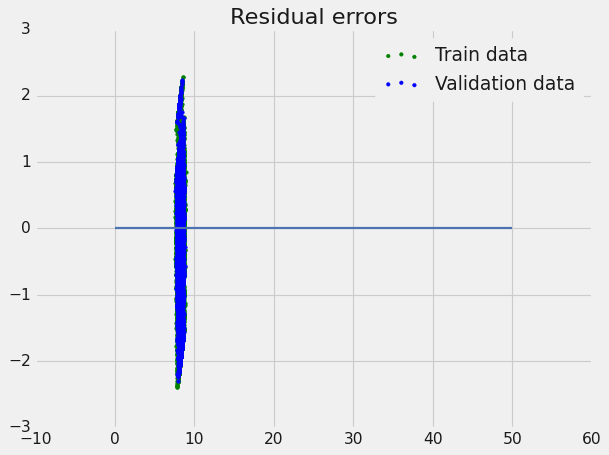

In [39]:
## setting plot style
plt.style.use('fivethirtyeight')
  
## plotting residual errors in training data
plt.scatter(final_model.predict(X_train), final_model.predict(X_train) - y_train,
            color = "green", s = 10, label = 'Train data')
  
## plotting residual errors in Validation data
plt.scatter(preds_valid, preds_valid-y_valid,
            color = "blue", s = 10, label = 'Validation data')
  
## plotting line for zero residual error
plt.hlines(y = 0, xmin = 0, xmax = 50, linewidth = 2)
  
## plotting legend
plt.legend(loc = 'upper right')
  
## plot title
plt.title("Residual errors")
  
## method call for showing the plot
plt.show()

In [40]:
final_model.get_params

<bound method BaseEstimator.get_params of TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer()),
                                                                                                       ('RobustScaler',
                                                                                                        RobustScaler()),
                                                                                                       ('scaler',
                                                                                                        S

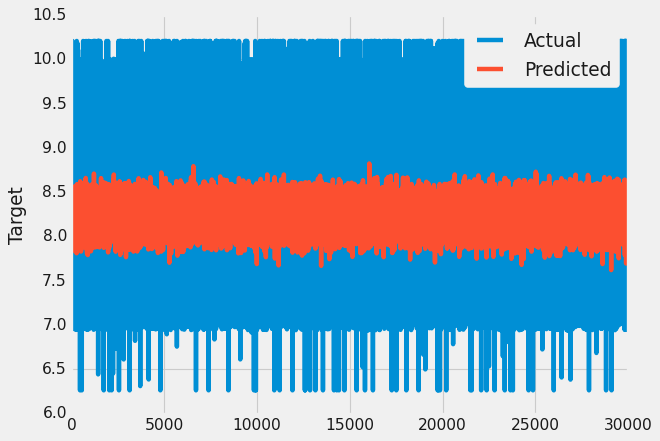

In [41]:
#Compare results
plt.plot(y_valid.values, label='Actual')
plt.plot(preds_valid, label='Predicted')
plt.ylabel('Target')

plt.legend()
plt.show()


# Step 5: Submit to the competition

We'll begin by using the trained model to generate predictions, which we'll save to a CSV file.

In [42]:
# Use the model to generate predictions
#predictions = final_model.predict(X_test)

# Save the predictions to a CSV file
output = pd.DataFrame({'Id': X_test.index,
                       'target': predictions})
output.to_csv('submission.csv', index=False)